# 第 7 讲：MuJoCo 实战——50 Hz 双环自行车平衡

前六讲分别研究了模型、反馈、极点配置、LQR、数字实现和 IMU 安装标定。本讲把这些模块连接到 MuJoCo 多刚体模型，完成纯平地自行车平衡。

最终结构为：

```text
MuJoCo IMU -> 安装旋转/零偏修正 -> [转向角, 滚转角, 滚转角速度]
                                  -> 极点配置或 LQR 外环 -> 期望转向角速度
                                  -> 50 Hz 转向速度 PI -> 转向电机转矩
后轮编码器   -> 50 Hz 速度 P 环    -> 后轮电机转矩
```

本讲会用完全相同的仿真条件比较极点配置和 LQR。

## 1. 控制模型与仿真对象

控制器内部仍使用三状态小角度模型；MuJoCo XML 则包含浮动基座、前后轮、转向关节、质量惯量、接触摩擦、传感器和两个转矩执行器。

这种安排有意保留模型误差：控制器不应该直接得到 MuJoCo 的完整状态方程。我们希望检查一个简单控制模型能否稳定更复杂的对象。当前 XML 已移除台阶，只测试接地平衡，不涉及空中姿态控制。

In [1]:
from dataclasses import dataclass
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib import font_manager
import mediapy as media
import mujoco
import numpy as np
from scipy.spatial.transform import Rotation

project_root = Path.cwd()
if not (project_root / "nominal_bike_control").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from nominal_bike_control import NominalBikeController, ScaleBikeModel

np.set_printoptions(precision=4, suppress=True)
plt.style.use("seaborn-v0_8-bright")
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
chinese_font = next((name for name in ["Arial Unicode MS", "PingFang HK", "Noto Sans CJK SC", "SimHei"] if name in available_fonts), "DejaVu Sans")
plt.rcParams.update({"font.sans-serif": [chinese_font], "axes.unicode_minus": False})
print("MuJoCo version:", mujoco.__version__)


MuJoCo version: 3.3.6


## 2. 实验参数

控制器每 20 ms 更新一次，即 50 Hz。MuJoCo 仍按 XML 中的 0.5 ms 积分。转向和后轮内环增益已经针对 50 Hz 的转矩零阶保持重新整定，不能换回旧的 500 Hz 参数。

In [2]:
@dataclass(frozen=True)
class Config:
    duration: float = 3.0
    control_dt: float = 0.02
    record_dt: float = 0.02
    wheel_radius: float = 0.07
    target_speed: float = 2.7
    acceleration_time: float = 1.5
    min_scheduling_speed: float = 1.0
    balance_start_time: float = 0.1
    max_steer_velocity: float = 10.0
    steer_kp: float = 0.01
    steer_ki: float = 0.01
    steer_integral_limit: float = 10.0
    rear_kp: float = 0.1
    rear_torque_limit: float = 2.0
    # R_BS：把 IMU 坐标中的向量转换到自行车坐标。当前 XML 中两者对齐。
    sensor_to_bike_rpy_deg: tuple[float, float, float] = (0.0, 0.0, 0.0)
    # 陀螺零偏在 IMU 坐标系中表示，单位 deg/s。
    gyro_bias_sensor_dps: tuple[float, float, float] = (0.0, 0.0, 0.0)

config = Config()
model_path = project_root / "model/orange_bike/orange_bike_horizontal.xml"
if not model_path.exists():
    raise FileNotFoundError(model_path)
print(config)
print("Model:", model_path)


Config(duration=3.0, control_dt=0.02, record_dt=0.02, wheel_radius=0.07, target_speed=2.7, acceleration_time=1.5, min_scheduling_speed=1.0, balance_start_time=0.1, max_steer_velocity=10.0, steer_kp=0.01, steer_ki=0.01, steer_integral_limit=10.0, rear_kp=0.1, rear_torque_limit=2.0, sensor_to_bike_rpy_deg=(0.0, 0.0, 0.0), gyro_bias_sensor_dps=(0.0, 0.0, 0.0))
Model: /Users/toutou/Desktop/jump_orange_mujocosim/model/orange_bike/orange_bike_horizontal.xml


## 3. 从 MuJoCo 传感器构造控制状态

- `steering_joint_pos_sensor` 给出 $\delta$；
- `ori_global` 给出 MuJoCo 顺序为 wxyz 的 IMU 姿态四元数；
- `gyro_local` 给出 IMU 三轴局部角速度；
- `rearwheel_joint_vel_sensor` 乘轮半径得到前进速度近似。

第 6 讲定义 $R_{BS}$ 为从 IMU 坐标系 S 到自行车坐标系 B 的固定安装旋转。角速度使用 $\omega_B=R_{BS}(\omega_S-b_S)$ 修正；姿态则使用 $R_{WB}=R_{WS}R_{BS}^{T}$ 修正。不能只取原始 `gyro_local[0]`，也不能直接从 IMU 欧拉角中减去安装欧拉角。

当前 XML 的 `imu_site` 设置为 `euler=0 0 0`，所以配置中的安装角和零偏默认为零。实车运行时应填入第 6 讲标定得到的参数。

In [3]:
def rotation_from_wxyz(quaternion):
    q = np.asarray(quaternion, dtype=float)
    xyzw = np.r_[q[1:], q[0]]
    return Rotation.from_quat(xyzw)


def sensor_to_bike_from_config(cfg):
    roll, pitch, yaw = np.deg2rad(cfg.sensor_to_bike_rpy_deg)
    return Rotation.from_euler("ZYX", [yaw, pitch, roll])


def bicycle_state_from_imu(steer, quaternion_wxyz, gyro_sensor,
                            sensor_to_bike, gyro_bias_sensor):
    world_from_sensor = rotation_from_wxyz(quaternion_wxyz)
    world_from_bike = world_from_sensor * sensor_to_bike.inv()
    yaw, pitch, roll = world_from_bike.as_euler("ZYX")

    p, q, r = sensor_to_bike.apply(
        np.asarray(gyro_sensor, dtype=float) - np.asarray(gyro_bias_sensor, dtype=float)
    )
    if abs(np.cos(pitch)) < 1e-3:
        raise ValueError("Pitch is too close to the Euler-angle singularity.")
    roll_rate = p + np.sin(roll) * np.tan(pitch) * q + np.cos(roll) * np.tan(pitch) * r
    state = np.array([[steer], [roll], [roll_rate]])
    return state, float(roll), float(roll_rate)


def make_controller(method, bike, cfg):
    common = dict(u_min=-cfg.max_steer_velocity, u_max=cfg.max_steer_velocity)
    if method == "pole":
        return NominalBikeController(
            bike.sys, method="place_multiple_poles", wc=-5.0, **common
        )
    if method == "lqr":
        return NominalBikeController(
            bike.sys, method="lqr",
            Qc=np.diag([4.0, 100.0, 2.0]), Rc=np.array([[10.0]]),
            **common,
        )
    raise ValueError("method must be 'pole' or 'lqr'")


## 4. 闭环执行顺序

每到一个 50 Hz 控制时刻：

1. 读取传感器；
2. 用前进速度更新三状态模型；
3. 重新计算极点配置或 LQR 增益；
4. 外环计算期望转向角速度；
5. 转向 PI 生成转矩；
6. 后轮 P 环生成驱动转矩；
7. 控制量保持不变，MuJoCo 继续以 0.5 ms 积分。

低速时模型使用至少 1 m/s 的正向调度速度，避免原 `Bike.updateSysParam` 在零速处把方向判成反向。起步前 0.1 s 暂不启动平衡外环。

In [4]:
def run_mujoco(method, cfg=config, render_video=False, video_fps=60):
    model = mujoco.MjModel.from_xml_path(str(model_path))
    data = mujoco.MjData(model)
    mujoco.mj_forward(model, data)

    bike = ScaleBikeModel(dt=cfg.control_dt, track_roll=False)
    controller = make_controller(method, bike, cfg)
    steer_id = model.actuator("cmd_steering_f").id
    rear_id = model.actuator("cmd_rearwheel_f").id
    steer_range = model.actuator_ctrlrange[steer_id]
    rear_range = model.actuator_ctrlrange[rear_id]

    names = ["time", "steer", "roll", "roll_rate", "speed", "speed_ref",
             "steer_rate", "steer_rate_ref", "steer_torque", "rear_torque",
             "x", "y", "z", "K_delta", "K_roll", "K_roll_rate"]
    history = {name: [] for name in names}
    next_control = 0.0
    next_record = 0.0
    steer_integral = 0.0
    sensor_to_bike = sensor_to_bike_from_config(cfg)
    gyro_bias_sensor = np.deg2rad(cfg.gyro_bias_sensor_dps)

    renderer = mujoco.Renderer(model, height=480, width=640) if render_video else None
    frames = []
    next_frame = 0.0
    try:
        while data.time < cfg.duration:
            if data.time + 1e-12 >= next_control:
                next_control += cfg.control_dt
                steer = float(data.sensor("steering_joint_pos_sensor").data[0])
                steer_rate = float(data.sensor("steering_joint_vel_sensor").data[0])
                rear_rate = float(data.sensor("rearwheel_joint_vel_sensor").data[0])
                state, roll, roll_rate = bicycle_state_from_imu(
                    steer,
                    data.sensor("ori_global").data,
                    data.sensor("gyro_local").data,
                    sensor_to_bike,
                    gyro_bias_sensor,
                )
                speed = cfg.wheel_radius * rear_rate

                scheduling_speed = max(abs(speed), cfg.min_scheduling_speed)
                bike.updateSysParam(scheduling_speed, min_forw_vel=cfg.min_scheduling_speed)
                controller.updateSysAndGain(bike.sys)
                steer_rate_ref = float(controller.step([[0.0]], state, data.time)[0, 0])
                if data.time < cfg.balance_start_time:
                    steer_rate_ref = 0.0

                steer_error = steer_rate_ref - steer_rate
                steer_integral = float(np.clip(
                    steer_integral + steer_error * cfg.control_dt,
                    -cfg.steer_integral_limit, cfg.steer_integral_limit,
                ))
                steer_torque = cfg.steer_kp * steer_error + cfg.steer_ki * steer_integral
                steer_torque = float(np.clip(steer_torque, steer_range[0], steer_range[1]))

                speed_ref = min(data.time / cfg.acceleration_time * cfg.target_speed, cfg.target_speed)
                rear_rate_ref = speed_ref / cfg.wheel_radius
                rear_torque = cfg.rear_kp * (rear_rate_ref - rear_rate)
                rear_lower = max(rear_range[0], -cfg.rear_torque_limit)
                rear_upper = min(rear_range[1], cfg.rear_torque_limit)
                rear_torque = float(np.clip(rear_torque, rear_lower, rear_upper))
                data.ctrl[steer_id] = steer_torque
                data.ctrl[rear_id] = rear_torque

                if data.time + 1e-12 >= next_record:
                    next_record += cfg.record_dt
                    position = data.sensor("pos_global").data.copy()
                    values = [data.time, steer, roll, roll_rate, speed, speed_ref,
                              steer_rate, steer_rate_ref, steer_torque, rear_torque,
                              position[0], position[1], position[2],
                              controller.K[0,0], controller.K[0,1], controller.K[0,2]]
                    for name, value in zip(names, values):
                        history[name].append(float(value))

            mujoco.mj_step(model, data)
            if renderer is not None and data.time + 1e-12 >= next_frame:
                next_frame += 1.0 / video_fps
                renderer.update_scene(data, camera="chasis_camera")
                frames.append(renderer.render().copy())
    finally:
        if renderer is not None:
            renderer.close()

    return {name: np.asarray(values) for name, values in history.items()}, frames, controller, model


## 5. 在完全相同条件下比较两种外环

下面连续运行两次全新仿真。不要在同一个 `MjData` 上接着运行第二个控制器，否则初始条件不公平。

In [5]:
experiments = {}
for method in ["pole", "lqr"]:
    history, _, controller, model = run_mujoco(method, render_video=False)
    experiments[method] = history
    max_roll = np.rad2deg(np.max(np.abs(history["roll"])))
    rms_roll = np.rad2deg(np.sqrt(np.mean(history["roll"]**2)))
    rms_torque = np.sqrt(np.mean(history["steer_torque"]**2))
    print(f"{method:4s}: max roll={max_roll:.3f} deg, RMS roll={rms_roll:.3f} deg, "
          f"RMS steer torque={rms_torque:.5f} N m, final speed={history['speed'][-1]:.3f} m/s")
    assert np.all(np.isfinite(history["roll"]))
    assert max_roll < 10.0


pole: max roll=2.181 deg, RMS roll=0.893 deg, RMS steer torque=0.00154 N m, final speed=2.700 m/s
lqr : max roll=3.179 deg, RMS roll=1.252 deg, RMS steer torque=0.00093 N m, final speed=2.700 m/s


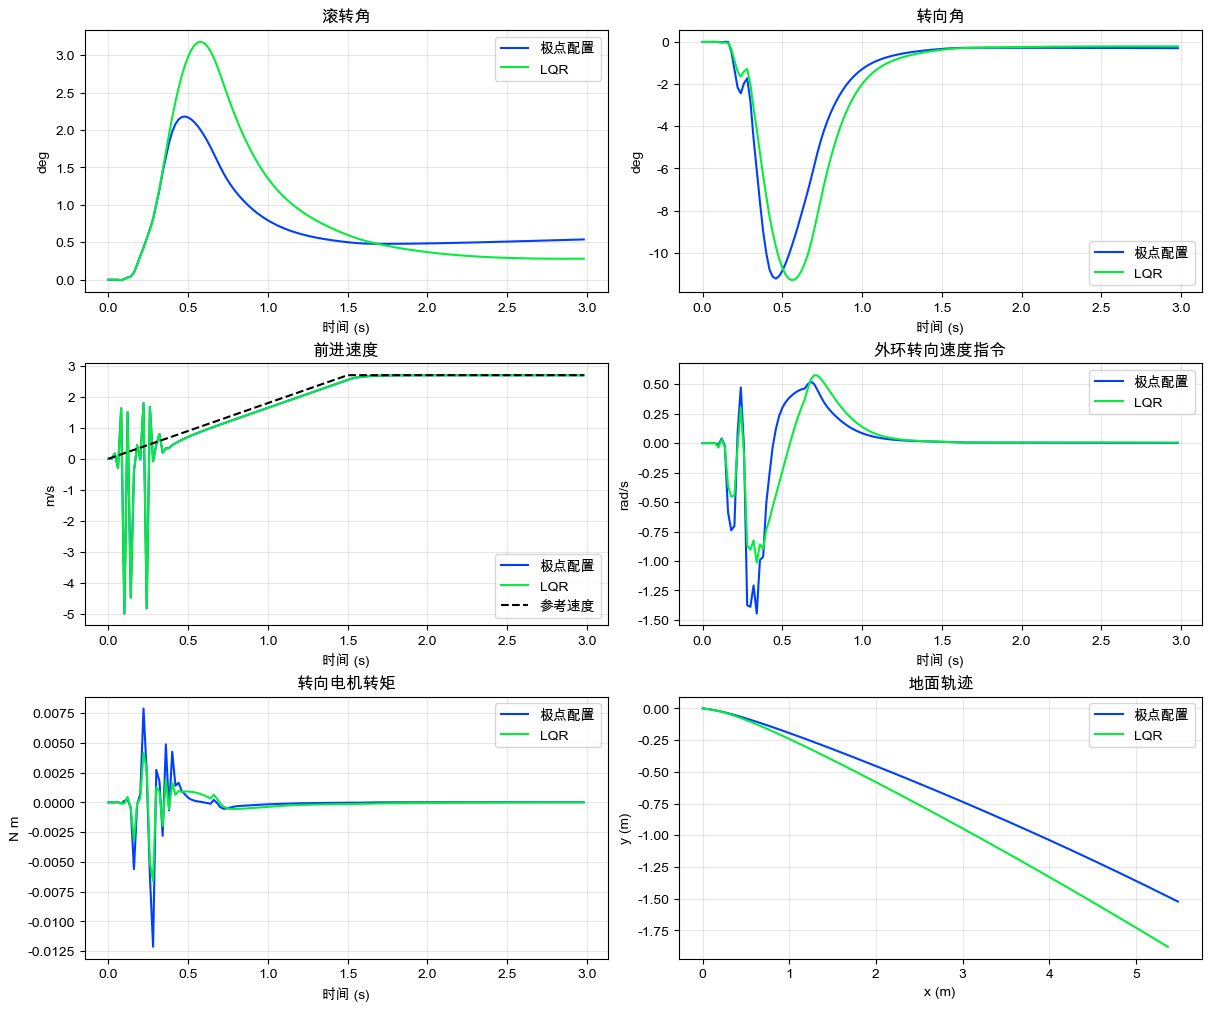

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10), constrained_layout=True)
labels = {"pole": "极点配置", "lqr": "LQR"}
for method, history in experiments.items():
    t = history["time"]
    label = labels[method]
    axes[0,0].plot(t, np.rad2deg(history["roll"]), label=label)
    axes[0,1].plot(t, np.rad2deg(history["steer"]), label=label)
    axes[1,0].plot(t, history["speed"], label=label)
    axes[1,1].plot(t, history["steer_rate_ref"], label=label)
    axes[2,0].plot(t, history["steer_torque"], label=label)
    axes[2,1].plot(history["x"], history["y"], label=label)
axes[1,0].plot(experiments["pole"]["time"], experiments["pole"]["speed_ref"],
               color="black", linestyle="--", label="参考速度")
titles = ["滚转角", "转向角", "前进速度", "外环转向速度指令", "转向电机转矩", "地面轨迹"]
ylabels = ["deg", "deg", "m/s", "rad/s", "N m", "y (m)"]
for axis, title, ylabel in zip(axes.flat, titles, ylabels):
    axis.set_title(title)
    axis.set_ylabel(ylabel)
    axis.grid(True, alpha=0.3)
    axis.legend()
for axis in axes[:2,:].flat:
    axis.set_xlabel("时间 (s)")
axes[2,0].set_xlabel("时间 (s)")
axes[2,1].set_xlabel("x (m)")
plt.show()


## 6. 查看增益调度

起步阶段速度从 0 增加到 2.7 m/s，控制模型随速度变化。下面直接画出三个反馈增益。低速阶段使用 1 m/s 下限，所以开始时增益保持不变。

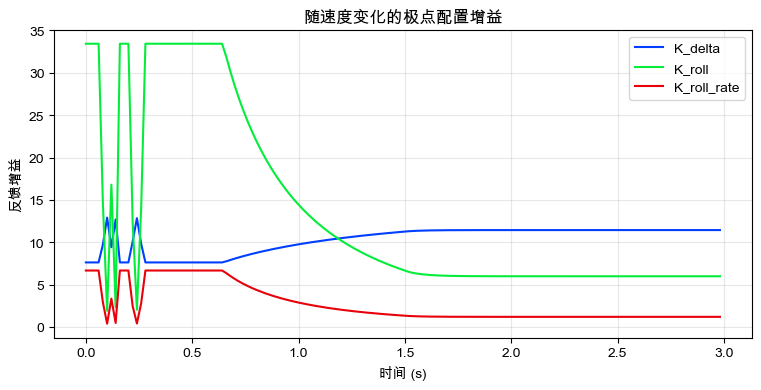

In [7]:
history = experiments["pole"]
plt.figure(figsize=(9, 4))
plt.plot(history["time"], history["K_delta"], label="K_delta")
plt.plot(history["time"], history["K_roll"], label="K_roll")
plt.plot(history["time"], history["K_roll_rate"], label="K_roll_rate")
plt.xlabel("时间 (s)")
plt.ylabel("反馈增益")
plt.title("随速度变化的极点配置增益")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 7. 可选：在 notebook 中渲染视频

macOS 的 `launch_passive` 要求整个进程由 `mjpython` 启动，普通 Jupyter 内核不能直接打开被动 viewer。这里使用离屏渲染并内嵌 MP4。打开开关会重新运行一次仿真。

In [8]:
RENDER_VIDEO = False
if RENDER_VIDEO:
    _, frames, _, _ = run_mujoco("pole", render_video=True, video_fps=60)
    media.show_video(frames, fps=60, width=720)


## 8. 从仿真走向真实车之前

至少完成以下检查：

- 核对滚转角、陀螺仪和转向角的正方向；
- 测量真实控制周期及其抖动，不只看设定值；
- 核对电机驱动器接受的是位置、速度、电流还是转矩；
- 从低转矩限幅、支撑架和急停开始；
- 标定轮径、轴距、质心和转向零位；
- 记录所有状态、命令、饱和标志和时间戳；
- 先验证内环，再闭合平衡外环；
- 不要把 MuJoCo 中成功直接等同于实车安全。

## 综合练习

1. 将控制频率改成 25 Hz，但暂不改内环增益，观察结果；随后重新整定。
2. 将初始车身姿态在 XML 或 `qpos` 中偏置 $2^\circ$，比较恢复过程。
3. 分别改变极点位置和 LQR 的 $R$，画出“滚转 RMS—转向转矩 RMS”权衡图。
4. 给 IMU 数据注入固定安装误差和陀螺零偏，比较直接读取单轴与第 6 讲坐标修正后的状态反馈。
5. 固定 2 m/s 设计增益并关闭调度，再运行加速过程，比较调度前后。
6. 为控制器增加安全状态机：滚转角超过阈值时停止驱动并清空积分。
7. 写一份实验报告，必须包含模型假设、控制器公式、采样率、饱和限制、指标和失败案例，而不只展示成功视频。